## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

In [0]:
import tensorflow as tf

import numpy as np
import pandas as pd
from sklearn import metrics
import matplotlib.pyplot as plt
%matplotlib inline

### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [0]:
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

### Find no.of samples are there in training and test datasets

In [53]:
print ("Num of Samples for Train =", x_train.shape[0])
print ("Num of Samples for Test =", x_test.shape[0])

Num of Samples for Train = 60000
Num of Samples for Test = 10000


### Find dimensions of an image in the dataset

In [54]:
x_train.shape

(60000, 28, 28)

In [55]:
x_test.shape

(10000, 28, 28)

### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [0]:
#Encoding the output class label (One-Hot Encoding)
y_train= tf.keras.utils.to_categorical(y_train,10)
y_test= tf.keras.utils.to_categorical(y_test,10)

In [57]:
len(y_train)

60000

### Normalize both the train and test image data from 0-255 to 0-1

In [0]:
x_train= x_train.astype('float32')
x_train/=255

x_test= x_test.astype('float32')
x_test/=255

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

In [0]:
x_train = x_train.reshape(x_train.shape[0],28,28,1)
x_test = x_test.reshape(x_test.shape[0],28,28,1)

### Import the necessary layers from keras to build the model

In [0]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Activation,Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D

### Build a model 

** with 2 Conv layers having `32 3x3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [0]:
model=Sequential()
model.add(Conv2D(32,kernel_size=(3,3), input_shape=(28,28,1),activation='relu'))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))

In [0]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [0]:
early_stop_cbk = tf.keras.callbacks.EarlyStopping(patience=5)

In [71]:
model = model.fit(x_train, y_train, batch_size=200, nb_epoch=10, verbose=1, validation_data=(x_test,y_test), callbacks = [early_stop_cbk])

W0818 10:14:06.482037 140607738181504 training.py:593] The `nb_epoch` argument in `fit` has been renamed `epochs`.


Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 4s 64us/sample - loss: 0.4780 - acc: 0.8339 - val_loss: 0.3493 - val_acc: 0.8800
Epoch 2/10
60000/60000 [==============================] - 4s 60us/sample - loss: 0.3010 - acc: 0.8917 - val_loss: 0.2948 - val_acc: 0.8972
Epoch 3/10
60000/60000 [==============================] - 4s 60us/sample - loss: 0.2600 - acc: 0.9069 - val_loss: 0.2763 - val_acc: 0.9002
Epoch 4/10
60000/60000 [==============================] - 4s 60us/sample - loss: 0.2381 - acc: 0.9140 - val_loss: 0.2620 - val_acc: 0.9053
Epoch 5/10
60000/60000 [==============================] - 4s 61us/sample - loss: 0.2154 - acc: 0.9229 - val_loss: 0.2540 - val_acc: 0.9107
Epoch 6/10
60000/60000 [==============================] - 4s 61us/sample - loss: 0.1996 - acc: 0.9266 - val_loss: 0.2402 - val_acc: 0.9170
Epoch 7/10
60000/60000 [==============================] - 4s 61us/sample - loss: 0.1859 - acc: 0.9324 - val_loss: 0.

### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

In [0]:
model=Sequential()
model.add(Conv2D(32, kernel_size=(3,3),input_shape=(28,28,1),activation='relu'))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))

### Now, to the above model, lets add Data Augmentation 

### Import the ImageDataGenrator from keras and fit the training images

In [0]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True)

# compute quantities required for featurewise normalization
# (std, mean, and principal components if ZCA whitening is applied)
datagen.fit(x_train)

#### Showing 5 versions of the first image in training dataset using image datagenerator.flow()

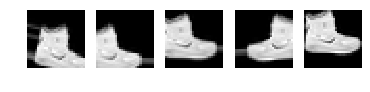

In [74]:
from matplotlib import pyplot as plt
gen = datagen.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()

### Run the above model using fit_generator()

In [0]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [76]:
model.summary()

Model: "sequential_8"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_10 (Conv2D)           (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_11 (Conv2D)           (None, 24, 24, 64)        18496     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 12, 12, 64)        0         
_________________________________________________________________
dropout_2 (Dropout)          (None, 12, 12, 64)        0         
_________________________________________________________________
flatten_5 (Flatten)          (None, 9216)              0         
_________________________________________________________________
dense_10 (Dense)             (None, 128)               1179776   
_________________________________________________________________
dense_11 (Dense)             (None, 10)               

In [77]:
# fits the model on batches with real-time data augmentation:
model.fit_generator(datagen.flow(x_train, y_train, batch_size=32),
                    steps_per_epoch=len(x_train) / 32, epochs=10,  validation_data=datagen.flow(x_test, y_test, batch_size=32))

Epoch 1/10
1875/1875 [==============================] - 22s 12ms/step - loss: 0.7629 - acc: 0.7156 - val_loss: 0.6049 - val_acc: 0.7735
Epoch 2/10
1875/1875 [==============================] - 22s 12ms/step - loss: 0.5663 - acc: 0.7883 - val_loss: 0.5229 - val_acc: 0.8043
Epoch 3/10
1875/1875 [==============================] - 22s 12ms/step - loss: 0.5056 - acc: 0.8107 - val_loss: 0.4693 - val_acc: 0.8240
Epoch 4/10
1875/1875 [==============================] - 22s 12ms/step - loss: 0.4739 - acc: 0.8240 - val_loss: 0.4669 - val_acc: 0.8287
Epoch 5/10
1875/1875 [==============================] - 22s 12ms/step - loss: 0.4540 - acc: 0.8304 - val_loss: 0.4524 - val_acc: 0.8332
Epoch 6/10
1875/1875 [==============================] - 22s 12ms/step - loss: 0.4386 - acc: 0.8363 - val_loss: 0.4273 - val_acc: 0.8462
Epoch 7/10
1875/1875 [==============================] - 22s 12ms/step - loss: 0.4237 - acc: 0.8436 - val_loss: 0.4150 - val_acc: 0.8497
Epoch 8/10
1875/1875 [==========================

###  Report the final train and validation accuracy

In [90]:
print ("Train-Accuracy with Image-Augmentation= 0.8540")

Train-Accuracy with Image-Augmentation= 0.8540


In [91]:
print ("Validation-Accuracy  with Image-Augmentation= 0.8604")

Validation-Accuracy  with Image-Augmentation= 0.8604


## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

In [0]:
import tensorflow as tf
import matplotlib.pyplot as plt

### **Load CIFAR10 dataset**

In [0]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

In [82]:
x_train.shape

(50000, 32, 32, 3)

In [83]:
y_train.shape

(50000, 1)

In [84]:
x_test.shape

(10000, 32, 32, 3)

In [85]:
y_test.shape

(10000, 1)

### **Create a data_gen funtion to genererator with image rotation,shifting image horizontally and vertically with random flip horizontally.**

In [0]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True)

### **Prepare/fit the generator.**

In [0]:
# compute quantities required for featurewise normalization
# (std, mean, and principal components if ZCA whitening is applied)
datagen.fit(x_train)

### **Generate 5 images for 1 of the image of CIFAR10 train dataset.**

W0818 10:21:21.705191 140607738181504 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 10:21:21.723507 140607738181504 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 10:21:21.741765 140607738181504 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 10:21:21.757417 140607738181504 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 10:21:21.772793 140607738181504 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


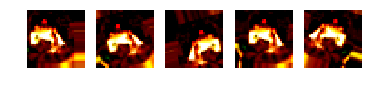

In [89]:
from matplotlib import pyplot as plt
gen = datagen.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze())
    plt.plot()
plt.show()